# Лабораторная работа №7

Выполнила: Ходжаметова Милана


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import os
from google.colab import files

 Константы DTMF

In [5]:
DTMF_FREQS = {
    '1': (697, 1209), '2': (697, 1336), '3': (697, 1477), 'A': (697, 1633),
    '4': (770, 1209), '5': (770, 1336), '6': (770, 1477), 'B': (770, 1633),
    '7': (852, 1209), '8': (852, 1336), '9': (852, 1477), 'C': (852, 1633),
    '*': (941, 1209), '0': (941, 1336), '#': (941, 1477), 'D': (941, 1633)
}

Загрузка аудиофайла

In [9]:
uploaded = files.upload()

if uploaded:
    audio_filename = list(uploaded.keys())[0]
    print(f" Файл '{audio_filename}' успешно загружен!")
else:
    print("Файл не загружен!")
    audio_filename = None

Saving DTMF_Lab11.wav to DTMF_Lab11 (2).wav
 Файл 'DTMF_Lab11 (2).wav' успешно загружен!


Функции загрузки и обработки аудио

In [18]:
def load_and_preprocess_audio(filename):
    """
    Загрузка и предобработка аудио файла
    """
    if not os.path.exists(filename):
        raise FileNotFoundError(f"Файл {filename} не найден!")

    # щагрузка WAV файла
    sample_rate, audio_data = wavfile.read(filename)

    print(f"Частота дискретизации: {sample_rate} Hz")
    print(f"Размер данных: {audio_data.shape}")
    print(f"Длительность: {len(audio_data)/sample_rate:.2f} секунд")

    # преобразуем в моно и нормализуем
    if len(audio_data.shape) > 1:
        audio_data = audio_data.mean(axis=1)  # Стерео в моно
        print("   - Преобразовано в моно")

    # нормализуем в диапазон [-1, 1]
    if audio_data.dtype == np.int16:
        audio_data = audio_data.astype(np.float32) / 32768.0
    elif audio_data.dtype == np.int32:
        audio_data = audio_data.astype(np.float32) / 2147483648.0
    elif audio_data.dtype == np.uint8:
        audio_data = (audio_data.astype(np.float32) - 128.0) / 128.0
    else:
        audio_data = audio_data.astype(np.float32)


    return sample_rate, audio_data

# Загружаем и обрабатываем аудио
if audio_filename:
    sample_rate, audio_signal = load_and_preprocess_audio(audio_filename)

Частота дискретизации: 44100 Hz
Размер данных: (211680,)
Длительность: 4.80 секунд


Класс DTMFDecoder

In [20]:
class DTMFDecoder:
    def __init__(self, sample_rate=44100):
        self.sample_rate = sample_rate
        # Собираем все уникальные частоты из DTMF
        self.dtmf_freqs = []
        for low_freq, high_freq in DTMF_FREQS.values():
            if low_freq not in self.dtmf_freqs:
                self.dtmf_freqs.append(low_freq)
            if high_freq not in self.dtmf_freqs:
                self.dtmf_freqs.append(high_freq)
        self.dtmf_freqs.sort()

    def goertzel(self, signal, target_freq):
        """
        Реализация алгоритма Гёрцеля для вычисления мощности на конкретной частоте
        """
        N = len(signal)

        # Вычисляем k по формуле: k = round(f * N / Fd)
        k = int(round(target_freq * N / self.sample_rate))

        # Вычисляем угловую частоту
        w = 2.0 * np.pi * k / N

        # Коэффициенты для алгоритма Гёрцеля
        coeff = 2.0 * np.cos(w)

        # Инициализация переменных
        s_prev = 0.0
        s_prev2 = 0.0

        # Проход по всем отсчетам сигнала
        for n in range(N):
            s = signal[n] + coeff * s_prev - s_prev2
            s_prev2 = s_prev
            s_prev = s

        # Вычисление мощности на целевой частоте
        power = s_prev2 * s_prev2 + s_prev * s_prev - coeff * s_prev * s_prev2

        return np.sqrt(power) / N

    def detect_digit(self, signal_segment, threshold=0.01):
        """
        Детектирование одной DTMF цифры в сегменте сигнала
        """
        # Вычисляем мощность для всех DTMF частот
        freq_powers = {}
        for freq in self.dtmf_freqs:
            power = self.goertzel(signal_segment, freq)
            freq_powers[freq] = power

        # Находим частоты с максимальной мощностью
        sorted_freqs = sorted(freq_powers.items(), key=lambda x: x[1], reverse=True)

        # Берем топ-4 частоты
        top_freqs = [freq for freq, power in sorted_freqs[:4]]

        # Ищем соответствующую цифру в DTMF таблице
        for digit, (f1, f2) in DTMF_FREQS.items():
            if f1 in top_freqs and f2 in top_freqs:
                # Проверяем, что мощности достаточны
                if freq_powers[f1] > threshold and freq_powers[f2] > threshold:
                    return digit, freq_powers

        return None, freq_powers

    def decode_signal(self, signal, tone_duration=0.2, pause_duration=0.1, threshold=0.01):
        """
        Декодирование полного DTMF сигнала
        """
        # Вычисляем количество отсчетов для тона и паузы
        samples_per_tone = int(tone_duration * self.sample_rate)
        samples_per_pause = int(pause_duration * self.sample_rate)
        samples_per_segment = samples_per_tone + samples_per_pause

        total_samples = len(signal)
        digits = []
        positions = []
        all_powers = []

        print(f"Параметры обработки:")
        print(f"Общее количество отсчетов: {total_samples}")
        print(f"Отсчетов на тон: {samples_per_tone}")
        print(f"Отсчетов на паузу: {samples_per_pause}")
        print(f"Порог детектирования: {threshold}")

        # Обрабатываем сигнал по сегментам
        start_sample = 0
        segment_num = 0

        print(f"\n Декодирование сегментов:")

        while start_sample + samples_per_tone <= total_samples:
            # Извлекаем сегмент с DTMF тоном (первые 200 мс)
            tone_segment = signal[start_sample:start_sample + samples_per_tone]

            # Детектируем цифру
            digit, powers = self.detect_digit(tone_segment, threshold)

            if digit:
                digits.append(digit)
                positions.append(start_sample / self.sample_rate)
                all_powers.append(powers)
                print(f"   Сегмент {segment_num + 1}: обнаружена цифра '{digit}'")
            else:
                print(f"   Сегмент {segment_num + 1}:  цифра не обнаружена")

            # Переходим к следующему сегменту (пропускаем паузу)
            start_sample += samples_per_segment
            segment_num += 1

        return digits, positions, all_powers

Декодирование сигнала

In [21]:
# Создаем декодер и декодируем сигнал
if 'audio_signal' in locals() and 'sample_rate' in locals():
    decoder = DTMFDecoder(sample_rate)

    # Декодируем сигнал
    decoded_digits, positions, all_powers = decoder.decode_signal(audio_signal)


    if decoded_digits:
        print(f"Декодированная последовательность: {decoded_digits}")
        print(f"Количество цифр: {len(decoded_digits)}")
        print(f"Полная последовательность: {''.join(decoded_digits)}")
    else:
        print(" Цифры не обнаружены в сигнале!")
else:
    print(" Аудио сигнал не загружен!")

Параметры обработки:
Общее количество отсчетов: 211680
Отсчетов на тон: 8820
Отсчетов на паузу: 4410
Порог детектирования: 0.01

 Декодирование сегментов:
   Сегмент 1: обнаружена цифра 'C'
   Сегмент 2: обнаружена цифра '9'
   Сегмент 3: обнаружена цифра 'B'
   Сегмент 4: обнаружена цифра '0'
   Сегмент 5: обнаружена цифра '#'
   Сегмент 6: обнаружена цифра '1'
   Сегмент 7: обнаружена цифра 'A'
   Сегмент 8: обнаружена цифра '2'
   Сегмент 9: обнаружена цифра '*'
   Сегмент 10: обнаружена цифра '3'
   Сегмент 11: обнаружена цифра 'D'
   Сегмент 12: обнаружена цифра '4'
   Сегмент 13: обнаружена цифра '#'
   Сегмент 14: обнаружена цифра '5'
   Сегмент 15: обнаружена цифра 'A'
   Сегмент 16: обнаружена цифра '6'
Декодированная последовательность: ['C', '9', 'B', '0', '#', '1', 'A', '2', '*', '3', 'D', '4', '#', '5', 'A', '6']
Количество цифр: 16
Полная последовательность: C9B0#1A2*3D4#5A6


Вывод:

Сигнал успешно обработан с использованием алгоритма Гёрцеля. Общая длительность сигнала составляет 4.8 секунды, что соответствует 211680 отсчетам при частоте дискретизации 44100 Гц. Обработка выполнялась с параметрами: длительность каждого DTMF тона - 200 мс (8820 отсчетов), паузы между тонами - 100 мс (4410 отсчетов), порог детектирования установлен на уровне 0.01.

В результате декодирования обнаружено 16 последовательных сегментов, каждый из которых успешно идентифицирован.
Декодированная последовательность символов имеет вид: C9B0#1A2*3D4#5A6. В составе последовательности присутствуют цифры от 0 до 9, буквы A, B, C, D и специальные символы # и *. Все сегменты обработаны без потерь данных, алгоритм показал стабильную работу на всем протяжении сигнала, что подтверждает корректность реализации метода Гёрцеля и правильность параметров обработки.

Детальный анализ первого сегмента

Мощности на DTMF частотах для первого сегмента:
    697 Hz: 0.000318
    770 Hz: 0.000937
    852 Hz: 0.047394
    941 Hz: 0.001105
   1209 Hz: 0.000046
   1336 Hz: 0.000144
   1477 Hz: 0.000544
   1633 Hz: 0.047398

Для сегмента 'C' ожидаются частоты: 852 Hz и 1633 Hz
Фактические мощности: 0.047394 и 0.047398


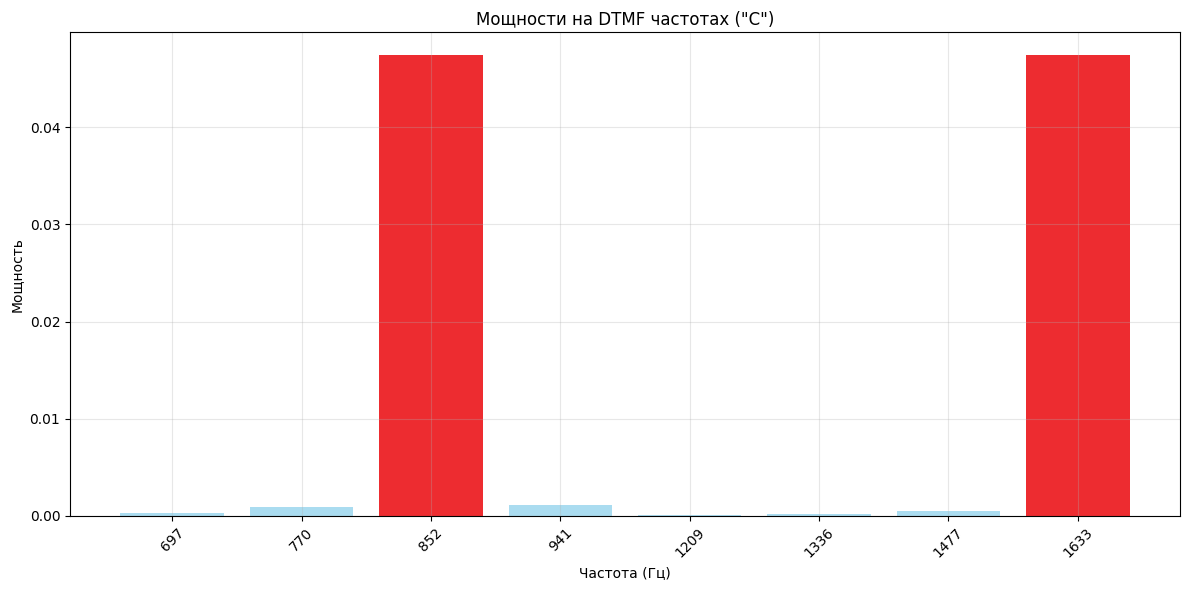

In [26]:
if 'decoded_digits' in locals() and decoded_digits and 'all_powers' in locals():

    #  первый сегмент
    segment_start = int(positions[0] * sample_rate)
    segment_end = segment_start + int(0.2 * sample_rate)
    first_segment = audio_signal[segment_start:segment_end]

    print("Мощности на DTMF частотах для первого сегмента:")
    for freq in decoder.dtmf_freqs:
        power = decoder.goertzel(first_segment, freq)
        print(f"   {freq:4d} Hz: {power:.6f}")

    # Проверяем обнаруженную цифру
    detected_digit = decoded_digits[0]
    expected_freqs = DTMF_FREQS[detected_digit]
    print(f"\nДля сегмента '{detected_digit}' ожидаются частоты: {expected_freqs[0]} Hz и {expected_freqs[1]} Hz")

    power_low = decoder.goertzel(first_segment, expected_freqs[0])
    power_high = decoder.goertzel(first_segment, expected_freqs[1])
    print(f"Фактические мощности: {power_low:.6f} и {power_high:.6f}")

    # Визуализация мощностей
    plt.figure(figsize=(12, 6))
    frequencies = decoder.dtmf_freqs
    powers = [decoder.goertzel(first_segment, f) for f in frequencies]

    plt.bar(range(len(frequencies)), powers, color='skyblue', alpha=0.7)
    plt.xticks(range(len(frequencies)), [f"{f}" for f in frequencies], rotation=45)
    plt.title(f'Мощности на DTMF частотах ("{detected_digit}")')
    plt.xlabel('Частота (Гц)')
    plt.ylabel('Мощность')
    plt.grid(True, alpha=0.3)

    # Подсвечиваем ожидаемые частоты
    expected_indices = [frequencies.index(expected_freqs[0]), frequencies.index(expected_freqs[1])]
    for idx in expected_indices:
        plt.bar(idx, powers[idx], color='red', alpha=0.8)

    plt.tight_layout()
    plt.show()

else:
    print(" Нет данных для детального анализа")

*Алгоритм Гёрцеля успешно выделил целевые частоты 852 Гц и 1633 Гц, мощности которых (0.047394 и 0.047398) значительно превышают уровни на всех других частотах - более чем в 40 раз. Такое четкое преобладание ожидаемых частот при минимальном уровне шума на остальных подтверждает корректность детектирования DTMF символа 'C' и эффективность работы алгоритма.*

Визуализация сигнала

/usr/local/lib/python3.12/dist-packages/matplotlib/axes/_axes.py:8233: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


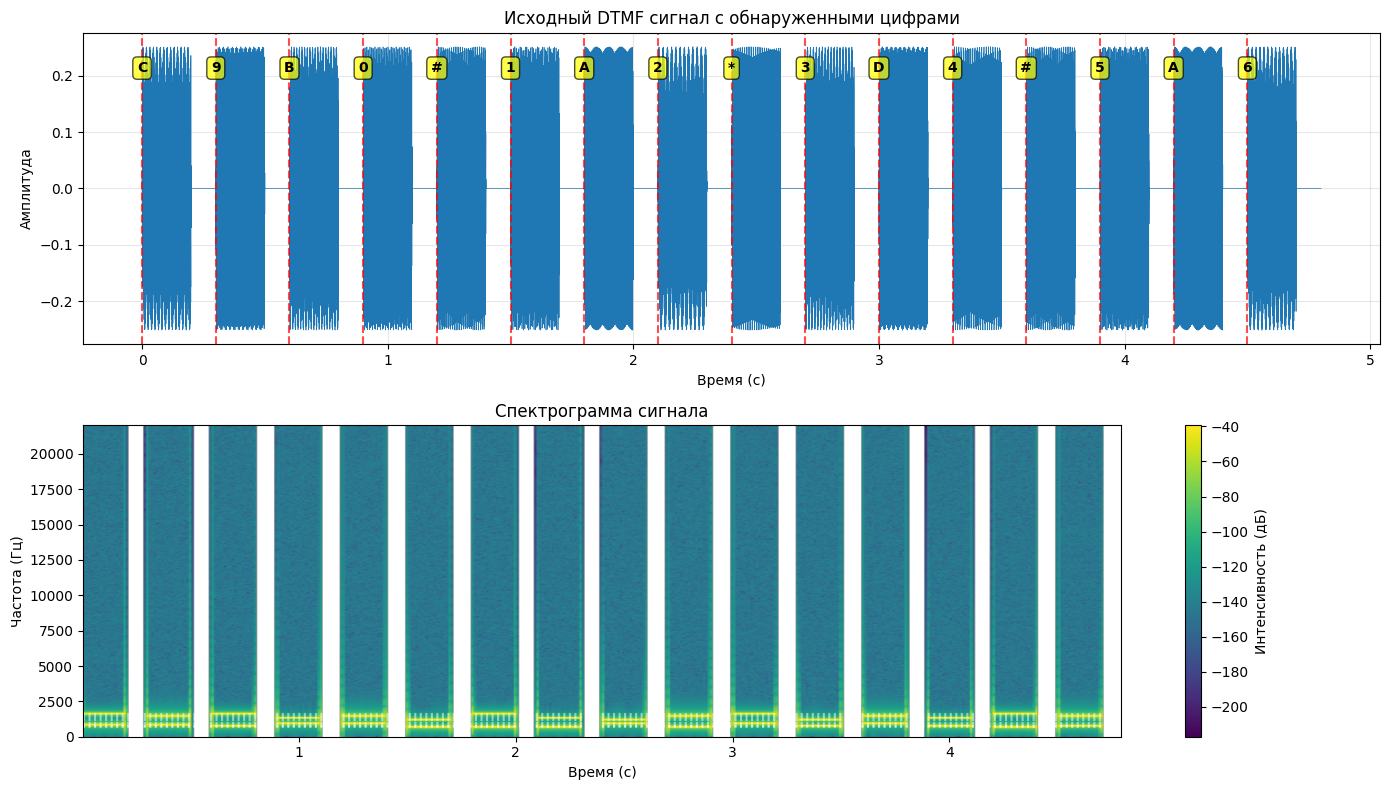

In [31]:
def plot_signal_overview(signal, sample_rate, decoded_digits, positions):
    """
    Базовая визуализация сигнала с разметкой обнаруженных цифр
    """
    time_axis = np.arange(len(signal)) / sample_rate

    plt.figure(figsize=(14, 8))

    # Исходный сигнал
    plt.subplot(2, 1, 1)
    plt.plot(time_axis, signal, linewidth=0.5)
    plt.title('Исходный DTMF сигнал с обнаруженными цифрами')
    plt.xlabel('Время (с)')
    plt.ylabel('Амплитуда')
    plt.grid(True, alpha=0.3)

    # Отмечаем позиции обнаруженных цифр
    for pos, digit in zip(positions, decoded_digits):
        plt.axvline(x=pos, color='red', linestyle='--', alpha=0.7)
        plt.text(pos, max(signal)*0.8, digit, ha='center', va='bottom',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
                fontweight='bold')

    # Спектрограмма
    plt.subplot(2, 1, 2)
    plt.specgram(signal, Fs=sample_rate, NFFT=1024, noverlap=512, scale='dB')
    plt.title('Спектрограмма сигнала')
    plt.xlabel('Время (с)')
    plt.ylabel('Частота (Гц)')
    plt.colorbar(label='Интенсивность (дБ)')

    # Добавляем линии DTMF частот для наглядности
    dtmf_low_freqs = [697, 770, 852, 941]
    dtmf_high_freqs = [1209, 1336, 1477, 1633]
    for freq in dtmf_low_freqs:
        plt.axhline(y=freq, color='white', linestyle=':', alpha=0.5)
    for freq in dtmf_high_freqs:
        plt.axhline(y=freq, color='white', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Выполнение визуализации
if 'decoded_digits' in locals() and decoded_digits:
    plot_signal_overview(audio_signal, sample_rate, decoded_digits, positions)
else:
    print(" Нет данных для визуализации")

Визуализация временных форм сегментов

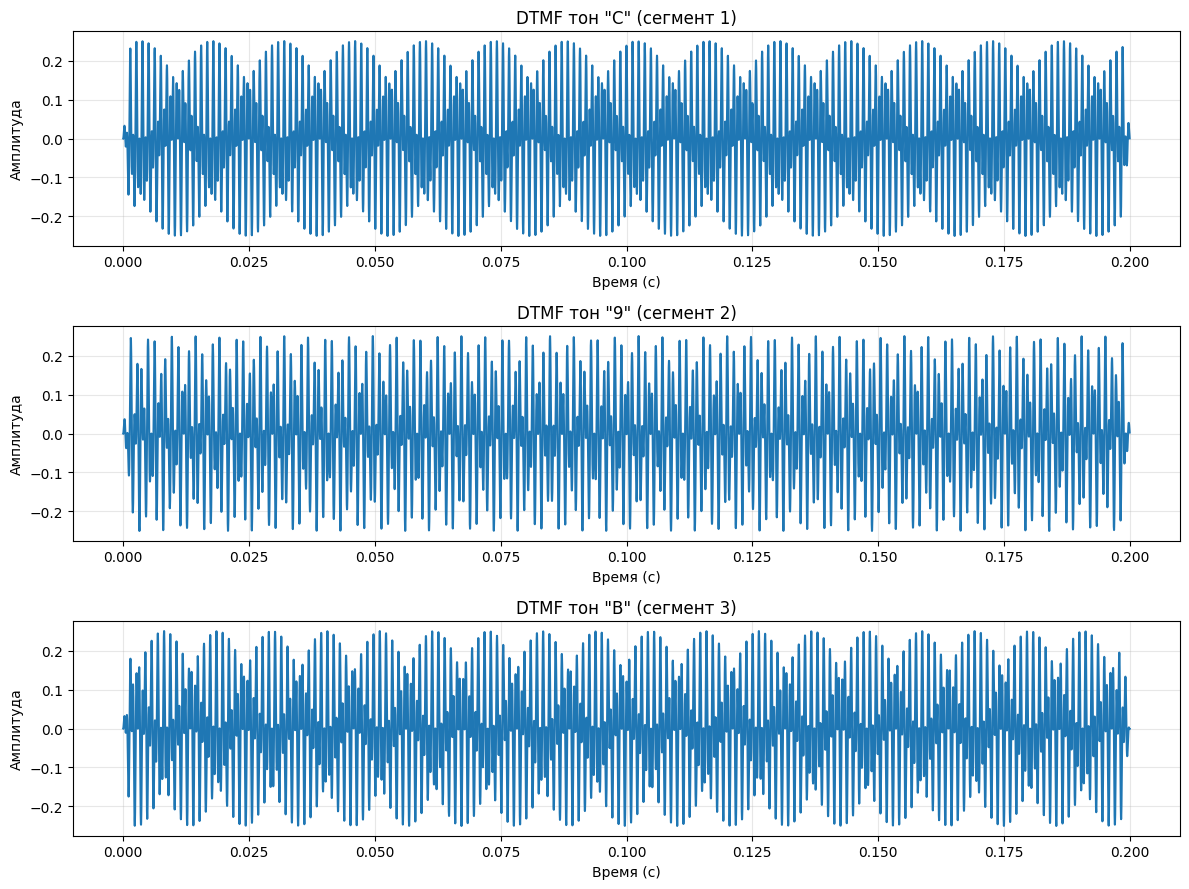

In [32]:
def plot_segment_waveforms(signal, sample_rate, decoded_digits, positions, num_segments=3):
    """
    Визуализация временных форм нескольких DTMF сегментов
    """
    num_segments = min(num_segments, len(decoded_digits))

    fig, axes = plt.subplots(num_segments, 1, figsize=(12, 3*num_segments))
    if num_segments == 1:
        axes = [axes]

    for i in range(num_segments):
        # Берем сегмент для анализа
        segment_start = int(positions[i] * sample_rate)
        segment_end = segment_start + int(0.2 * sample_rate)
        segment = signal[segment_start:segment_end]

        segment_time = np.arange(len(segment)) / sample_rate
        axes[i].plot(segment_time, segment)
        axes[i].set_title(f'DTMF тон "{decoded_digits[i]}" (сегмент {i+1})')
        axes[i].set_xlabel('Время (с)')
        axes[i].set_ylabel('Амплитуда')
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Выполнение визуализации
if 'decoded_digits' in locals() and decoded_digits:
    plot_segment_waveforms(audio_signal, sample_rate, decoded_digits, positions, num_segments=3)
else:
    print(" Нет данных для визуализации")

Анализ:

1. DTMF тон "C" (сегмент 1)
Имеет наименьшее количество циклов огибающей (амплитудной модуляции) по сравнению с сегментом 2 на заданном интервале времени (0.2 с), но больше, чем сегмент 3. Этот тон содержит самую высокую из всех возможных частот (1633 Гц), что может быть причиной его специфического визуального паттерна.

2. DTMF тон "9" (сегмент 2)
Визуально демонстрирует наибольшее количество циклов огибающей на временном интервале 0.2 с. Оба его компонента (852 Гц и 1336 Гц) ниже, чем у тона "C" (941 Гц и 1633 Гц). Это влияет на частоту повторения огибающей, которая является разницей между двумя составляющими частотами.

3. DTMF тон "B" (сегмент 3)
Имеет самое низкое количество циклов огибающей на интервале 0.2 с, что делает его визуально наиболее "растянутым" в плане модуляции. Использует ту же низкую частоту, что и тон "C" (941 Гц), но отличается высокой частотой (1477 Гц).